# hierarchical
> Plots for hierarchical clustering

In [ ]:
#| default_exp hierarchical

## Setup

In [ ]:
#| export
import pandas as pd,numpy as np,seaborn as sns
from tqdm import tqdm
from functools import partial
from tqdm.contrib.concurrent import process_map
from fastcore.meta import delegates
from scipy.cluster.hierarchy import fcluster,linkage,dendrogram
from scipy.spatial.distance import pdist, euclidean
from matplotlib import pyplot as plt
from cachetools import LRUCache

## Example dataset

In [ ]:
df0=sns.load_dataset("iris")
df0.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df0.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [ ]:
df = df0.drop(columns="species")

## Distance

Although pdist from scipy can calculate 1D distance of self matrix (row by row) with customized function, the function is limited without key on the vector. In this module, we'd like to make functions that can consider key in the vector when calculating distance between two vectors, so the input should take dataframe for datatable and pd.Series for vectors.

In [ ]:
def my_distance(u, v):
    "Manhattan distance"
    return np.sum(np.abs(u - v)) 

In [ ]:
A = np.array([[0, 0],
              [1, 1],
              [2, 2]])
pdist(A,metric=my_distance)

array([2., 4., 2.])

In [ ]:
pdist(df,metric=my_distance)

array([0.7, 0.8, 1. , ..., 1.2, 0.9, 1.5], shape=(11175,))

In [ ]:
pdist(df,metric=euclidean)

array([0.53851648, 0.50990195, 0.64807407, ..., 0.6164414 , 0.64031242,
       0.76811457], shape=(11175,))

In [ ]:
#| export
def get_1d_distance(df,func_flat):
    "Compute 1D distance (like pdist from scipy) but for df with column names"
    n = len(df)
    dist = []
    for i in tqdm(range(n)):
        for j in range(i+1, n):
            d = func_flat(df.iloc[i], df.iloc[j])
            dist.append(d)
    return np.array(dist)

In [ ]:
# return 1d distance
get_1d_distance(pd.DataFrame(A),func_flat=my_distance)

100%|██████████| 3/3 [00:00<00:00, 8823.92it/s]


array([2, 4, 2])

Parallel computing to accelerate when flattened pssms are too many in a df:

In [ ]:
#| hide
#| export
def get_distance(pair, df, func):
    i,j=pair
    return func(df.iloc[i], df.iloc[j])

In [ ]:
#| export
def get_1d_distance_parallel(df, func_flat, max_workers=4, chunksize=100):
    "Parallel compute 1D distance for each row in a dataframe given a distance function "
    n = len(df)
    index_pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    bound_worker = partial(get_distance, df=df, func=func_flat)

    dist = process_map(bound_worker, index_pairs, max_workers=max_workers, chunksize=chunksize)
    return np.array(dist)

In [ ]:
# get_1d_distance_parallel(df, func_flat=my_distance)

In [ ]:
#| export
_Z_CACHE = LRUCache(maxsize=50)

In [ ]:
#| export
def get_Z(pssms,func_flat,method='ward',parallel=True):
    "Get linkage matrix Z from pssms dataframe"
    key = id(pssms)
    if key not in _Z_CACHE:
        distance = get_1d_distance_parallel(pssms,func_flat=func_flat) if parallel else get_1d_distance(pssms,func_flat=func_flat)
        Z = linkage(distance, method=method)
        _Z_CACHE[key] =Z
    return _Z_CACHE[key]

In [ ]:
%%time
Z = get_Z(df,func_flat=euclidean,parallel=False)

100%|██████████| 150/150 [00:00<00:00, 539.11it/s]

CPU times: user 274 ms, sys: 5.29 ms, total: 279 ms
Wall time: 280 ms


In [ ]:
Z[:5]

array([[1.01e+02, 1.42e+02, 0.00e+00, 2.00e+00],
       [7.00e+00, 3.90e+01, 1.00e-01, 2.00e+00],
       [0.00e+00, 1.70e+01, 1.00e-01, 2.00e+00],
       [9.00e+00, 3.40e+01, 1.00e-01, 2.00e+00],
       [1.28e+02, 1.32e+02, 1.00e-01, 2.00e+00]])

In [ ]:
#| export
def plot_dendrogram(Z,
                    thr=0.07,
                    dense=4, # the higher the more dense for each row
                    line_width=1,
                    title=None,
                    scale=1,
                    **kwargs):
    length = (len(Z) + 1) // dense
    
    plt.figure(figsize=(5*scale,length*scale))
    with plt.rc_context({'lines.linewidth': line_width}):
        dendrogram(
            Z,
            orientation='left',
            leaf_font_size=7,
            color_threshold=thr,
            **kwargs
        )
    if title is not None: plt.title(title)
    plt.xlabel('Distance')
    # plt.savefig(output, bbox_inches='tight')
    # plt.close()
    ax = plt.gca()
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

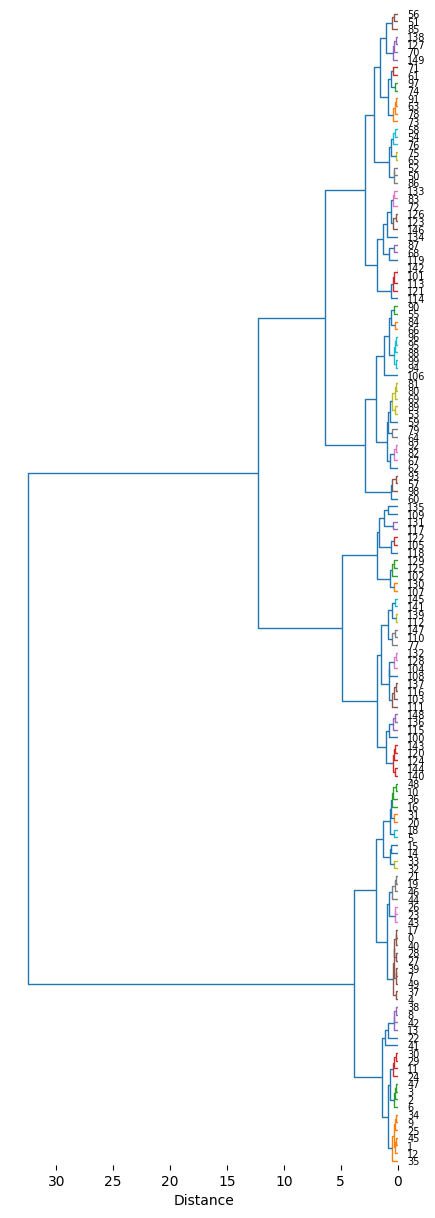

In [ ]:
plot_dendrogram(Z,dense=10,labels=df.index,thr=0.5)

## Pipeline

In [ ]:
#| export
def get_hcluster(df,thr=0.07,plot=True,labels=None,func_flat=euclidean,method='ward',**kwargs):
    "Get flat cluster assignments from hierarchical clustering linkage matrix `Z`."
    Z = get_Z(df,func_flat=func_flat,method=method)
    if plot: plot_dendrogram(Z,labels=labels if labels is not None else df.index,thr=thr,**kwargs)
    clusters = fcluster(Z, thr, criterion='distance')
    return pd.Series(clusters, index=df.index)

0      1
1      1
2      1
3      1
4      1
      ..
145    2
146    4
147    2
148    2
149    4
Length: 150, dtype: int32

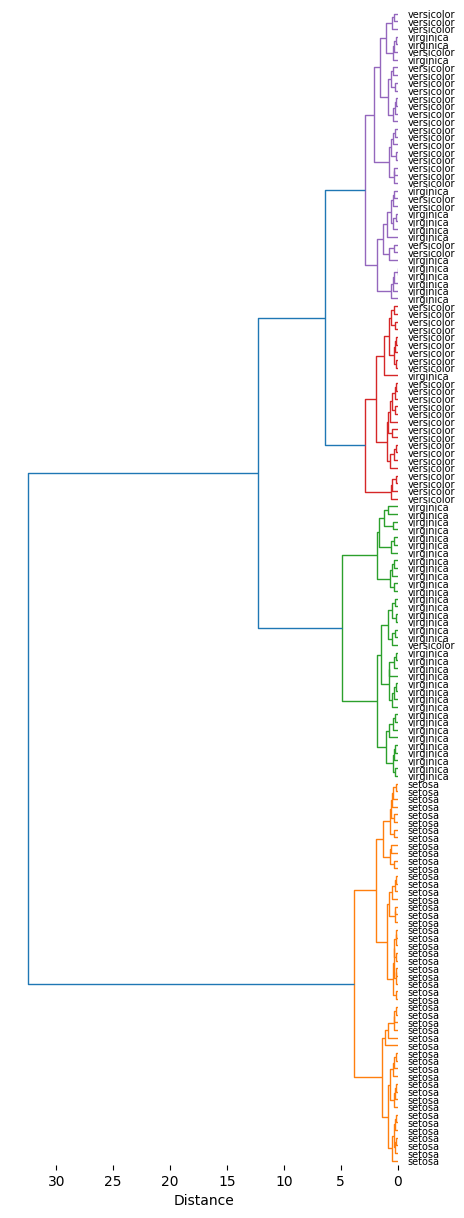

In [ ]:
get_hcluster(df,labels=df0['species'].tolist(),thr=5,dense=10)

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()